In [1]:
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
!mv -f ratings_*.txt ~/work/sentiment_classification/data


--2026-04-10 07:16:19--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  45.0MB/s    in 0.3s    

2026-04-10 07:16:20 (45.0 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-04-10 07:16:20--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet

In [2]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh
!python --version
!pip install gensim==4.3.2
# 의존성 연결을 위해 다운그레이드를 진행합니다.
!pip install scipy==1.12.0 numpy==1.26.3


Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 5.26 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/home/jovyan/work/AIFFEL_quest_rs/AIFFEL_quest_rs/Exploration/Ex5/Mecab-ko-for-Google-Colab
install_mecab-ko_on_colab_light_220429.sh: line 4: cd: /content: No such file or directory
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-04-10 07:16:43--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 13.200.41.136, 13.200.41.134, 13.200.41.135, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.136|:443... connected.
HTTP request sent, awaiting response

In [11]:
import pandas
import konlpy
import gensim
import pandas as pd
import os


# 데이터를 읽어봅시다.
train_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_train.txt')
test_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_test.txt')

print(train_data.head())

print(pandas.__version__)
print(konlpy.__version__)
print(gensim.__version__)

         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1
2.3.0
0.6.0
4.3.2


In [12]:
from konlpy.tag import Mecab
import numpy as np
from collections import Counter

tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(10000-4)
    vocab = ['', '', '', ''] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index[''] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

In [13]:
index_to_word = {index:word for word, index in word_to_index.items()}

In [14]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수입니다.
# 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수입니다.
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

## 1. 라이브러리 import, 데이터 로드

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


from konlpy.tag import Mecab
from collections import Counter
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
# NSMC 데이터셋 불러오기
train_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_train.txt')
test_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_test.txt')

# 형태소 분석기
tokenizer = Mecab()

# 제거할 불용어 목록
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

## 2. 데이터 전처리 및 토큰화

In [2]:
def load_data(train_data, test_data, num_words=10000):

    # 중복 리뷰 제거
    train_data.drop_duplicates(subset=['document'], inplace=True)
    test_data.drop_duplicates(subset=['document'], inplace=True)

    # 결측치 제거
    train_data = train_data.dropna(how='any')
    test_data = test_data.dropna(how='any')

    X_train, X_test = [], []

    # 형태소 분석 + 불용어 제거
    for sentence in train_data['document']:
        tokens = tokenizer.morphs(sentence)
        tokens = [word for word in tokens if word not in stopwords]
        X_train.append(tokens)

    for sentence in test_data['document']:
        tokens = tokenizer.morphs(sentence)
        tokens = [word for word in tokens if word not in stopwords]
        X_test.append(tokens)

    # 전체 단어 빈도 계산
    words = np.concatenate(X_train).tolist()
    counter = Counter(words)

    # 상위 num_words 단어만 사용
    counter = counter.most_common(num_words - 4)

    # 특수 토큰 + 단어 vocab 생성
    vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [key for key, _ in counter]

    # 단어 → 인덱스 딕셔너리
    word_to_index = {word: index for index, word in enumerate(vocab)}

    # 문장을 숫자 인덱스 리스트로 변환
    def wordlist_to_indexlist(wordlist):
        return [word_to_index['<BOS>']] + [
            word_to_index[word] if word in word_to_index else word_to_index['<UNK>']
            for word in wordlist
        ]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(train_data['label']), X_test, np.array(test_data['label']), word_to_index
# 데이터 전처리 실행
X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

# index → word 변환용 딕셔너리
index_to_word = {index: word for word, index in word_to_index.items()}

In [3]:
train_path = os.path.join(os.getenv("HOME"), "work/sentiment_classification/data/ratings_train.txt")
test_path = os.path.join(os.getenv("HOME"), "work/sentiment_classification/data/ratings_test.txt")

train_data = pd.read_table(train_path)
test_data = pd.read_table(test_path)

print(train_data.head())
print(train_data.shape, test_data.shape)

         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1
(150000, 3) (50000, 3)


## 3. 문장 길이 맞추기(padding)

In [13]:
def pad_sequences(sequences, maxlen, pad_value=0):
    padded = []

    for seq in sequences:
        seq = list(seq)  # numpy 배열이어도 list로 변환

        if len(seq) > maxlen:
            seq = seq[:maxlen]
        else:
            seq = seq + [pad_value] * (maxlen - len(seq))

        padded.append(seq)

    return np.array(padded)
# 최대 문장 길이
# 문장 길이를 동일하게 맞춤
max_len = 50
X_train = pad_sequences(X_train, max_len, pad_value=word_to_index['<PAD>'])
X_test = pad_sequences(X_test, max_len, pad_value=word_to_index['<PAD>'])

## 4. Train & validation set 분리

In [14]:
# train / validation 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

## 5. PyTorch Dataset 생성

In [15]:
# numpy → torch tensor 변환
X_train = torch.tensor(X_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# DataLoader 생성
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=64
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=64
)

# GPU 사용 여부
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 6. Word2Vec 없는 모델

In [19]:
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()

        # 단어 → 벡터 변환
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        # 문장 특징 추출
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True
        )

        # 최종 감성 분류
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        # embedding
        x = self.embedding(x)

        # LSTM
        _, (hidden, _) = self.lstm(x)

        # 마지막 hidden state 사용
        out = self.fc(hidden[-1]).squeeze(1)

        return out
def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0
    total_acc = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            loss = criterion(logits, y)

            # sigmoid → 확률
            preds = (torch.sigmoid(logits) >= 0.5).float()

            acc = (preds == y).float().mean()

            total_loss += loss.item()
            total_acc += acc.item()

    return total_loss / len(loader), total_acc / len(loader)
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(epochs):

        model.train()

        train_loss = 0
        train_acc = 0

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)

            loss = criterion(logits, y)

            loss.backward()

            optimizer.step()

            preds = (torch.sigmoid(logits) >= 0.5).float()

            acc = (preds == y).float().mean()

            train_loss += loss.item()
            train_acc += acc.item()

        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc / len(train_loader))
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Acc {history['train_acc'][-1]:.4f} | "
            f"Val Acc {val_acc:.4f}"
        )

    return history
model_random = LSTMClassifier(
    vocab_size=len(word_to_index),
    embed_dim=100,
    hidden_dim=128
).to(device)

history_random = train_model(
    model_random,
    train_loader,
    val_loader,
    epochs=10
)

Epoch 1/10 | Train Acc 0.5113 | Val Acc 0.5676
Epoch 2/10 | Train Acc 0.5752 | Val Acc 0.8034
Epoch 3/10 | Train Acc 0.8330 | Val Acc 0.8454
Epoch 4/10 | Train Acc 0.8654 | Val Acc 0.8548
Epoch 5/10 | Train Acc 0.8827 | Val Acc 0.8561
Epoch 6/10 | Train Acc 0.8994 | Val Acc 0.8594
Epoch 7/10 | Train Acc 0.9152 | Val Acc 0.8562
Epoch 8/10 | Train Acc 0.9312 | Val Acc 0.8543
Epoch 9/10 | Train Acc 0.9459 | Val Acc 0.8506
Epoch 10/10 | Train Acc 0.9568 | Val Acc 0.8472


## 7. 그래프 시각화

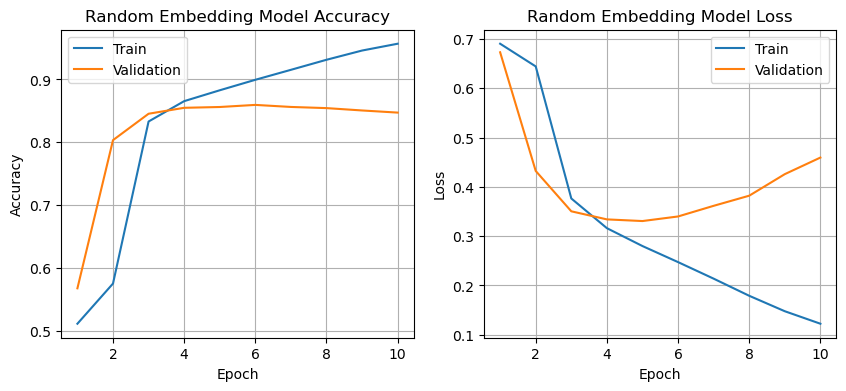

In [30]:
def plot_history(history, title):

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(10,4))

    # Accuracy 그래프
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_acc'], label='Train')
    plt.plot(epochs, history['val_acc'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title} Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss 그래프
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_loss'], label='Train')
    plt.plot(epochs, history['val_loss'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_history(history_random, "Random Embedding Model")

# 8. Word2Vec version

### 8-1 모델 로드 및 임베딩 행렬 생성

In [32]:
# 한국어 Word2Vec 모델 로드
word2vec_path = os.getenv("HOME") + '/work/sentiment_classification/data/word2vec_ko.model'

word2vec = Word2Vec.load(word2vec_path)

# 실제 단어 벡터는 wv에서 사용
kv = word2vec.wv

embedding_dim = kv.vector_size
vocab_size = len(word_to_index)

# 초기 임베딩 행렬
embedding_matrix = np.random.randn(vocab_size, embedding_dim)

# Word2Vec 벡터로 덮어쓰기
for word, idx in word_to_index.items():

    if word in kv:
        embedding_matrix[idx] = kv[word]

# padding 벡터는 0으로
embedding_matrix[word_to_index['<PAD>']] = np.zeros(embedding_dim)

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

# 8-2 Model 학습

In [33]:
class LSTMClassifierW2V(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim=128, pretrained_embeddings=None):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        # Word2Vec 임베딩 적용
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        out = self.fc(hidden[-1]).squeeze(1)

        return out
model_w2v = LSTMClassifierW2V(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=128,
    pretrained_embeddings=embedding_matrix
).to(device)

history_w2v = train_model(
    model_w2v,
    train_loader,
    val_loader,
    epochs=10
)

Epoch 1/10 | Train Acc 0.5227 | Val Acc 0.6705
Epoch 2/10 | Train Acc 0.8103 | Val Acc 0.8451
Epoch 3/10 | Train Acc 0.8615 | Val Acc 0.8551
Epoch 4/10 | Train Acc 0.8791 | Val Acc 0.8595
Epoch 5/10 | Train Acc 0.8925 | Val Acc 0.8620
Epoch 6/10 | Train Acc 0.9043 | Val Acc 0.8610
Epoch 7/10 | Train Acc 0.9166 | Val Acc 0.8610
Epoch 8/10 | Train Acc 0.9291 | Val Acc 0.8571
Epoch 9/10 | Train Acc 0.9393 | Val Acc 0.8542
Epoch 10/10 | Train Acc 0.9493 | Val Acc 0.8537


### 8-3 시각화

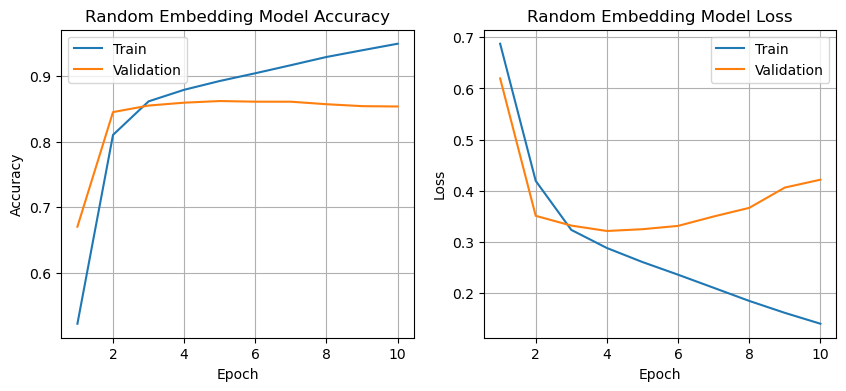

In [34]:
def plot_history(history, title):

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(10,4))

    # Accuracy 그래프
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_acc'], label='Train')
    plt.plot(epochs, history['val_acc'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title} Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss 그래프
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_loss'], label='Train')
    plt.plot(epochs, history['val_loss'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_history(history_w2v, "Random Embedding Model")

## 프로젝트: 네이버 영화리뷰 감성분석 도전
### 1. 프로젝트 개요  

본 프로젝트는 네이버 영화 리뷰(NSMC) 데이터셋을 활용한 감성 분석 모델 구현을 목표로 진행하였다.  
형태소 분석을 기반으로 텍스트 데이터를 전처리하고, 이를 LSTM 기반 분류 모델에 입력하여 긍정·부정 감성을 예측하였다.  또한 랜덤 임베딩(Random Embedding)과 사전학습 Word2Vec 임베딩을 각각 적용하여 모델 성능을 비교하였다.  

### 2. 데이터 전처리 과정  
(1) 데이터 정제

NSMC 데이터셋을 불러온 후 중복 리뷰 제거, 결측값 제거, 텍스트 데이터 형태소 분석, 불용어 제거를 수행하였다.
  
형태소 분석에는 Mecab을 사용하였다.  
  
(2) 토큰화 및 단어 사전 구축  
  
리뷰 문장을 형태소 단위로 분리한 뒤, 단어 빈도를 기반으로 상위 10,000개의 단어로 vocabulary를 구성하였다.
  
이 과정에서
  
단어 → index (word_to_index)
index → 단어 (index_to_word)
  
딕셔너리를 생성하였다.  
  
이후 각 문장을 단어 인덱스 시퀀스로 변환하였다.  
  
(3) 시퀀스 길이 정규화  
  
문장의 길이가 서로 다르기 때문에 모델 입력 형태를 맞추기 위해 padding을 적용하였다.  
  
최대 길이: max_len = 50  
길이가 긴 문장 → 잘라냄  
짧은 문장 → padding 추가  
  
이를 통해 모든 입력 데이터를 동일한 길이의 벡터로 변환하였다.  
  
### 3. 모델 설계
  
프로젝트에서는 LSTM 기반 문장 분류 모델을 사용하였다.  
  
주요 구성 요소:  
Embedding Layer: 단어 인덱스를 벡터로 변환한다.  
LSTM Layer: 문장의 순차적 정보를 학습한다.  
Fully Connected Layer: 최종 감성 분류를 수행한다.  

### 4. 실험 설계

성능 비교를 위해 두 가지 모델을 구성하였다.  
  
(1) Random Embedding 모델  
Embedding Layer를 랜덤 초기화  
학습 과정에서 임베딩 벡터가 업데이트됨  
(2) Word2Vec Embedding 모델  
사전 학습된 한국어 Word2Vec 모델 사용  
Word2Vec 벡터를 embedding layer의 초기값으로 설정  
  
이 두 모델을 동일한 학습 조건에서 학습시켜 성능을 비교하였다.  
  
### 5. 실험 결과
(1) Random Embedding  

최고 Validation Accuracy: 0.8594
  
(2) Word2Vec Embedding

최고 Validation Accuracy: 0.8620
  
성능 차이: 0.26%로 나타났다.  
  
### 6. 결과 해석

Word2Vec 임베딩을 적용한 모델이 소폭 높은 성능을 보였다.  
또한 학습 초기 단계에서 validation accuracy가 더 빠르게 상승하여 초기 수렴 속도 측면에서 장점이 나타났다.  
그러나 최종 성능 차이는 크지 않았다.  
이러한 결과는 다음과 같은 이유로 해석할 수 있다.  
- NSMC 데이터셋의 규모가 충분하여 랜덤 임베딩도 학습 과정에서 의미 있는 단어 표현을 학습할 수 있음
- LSTM 자체가 문맥 정보를 학습하면서 임베딩 표현을 보완함
- 사전학습 Word2Vec의 학습 도메인과 영화 리뷰 데이터 간 차이 가능성
### 7. 문제점 및 개선 방향

실험 과정에서 다음과 같은 한계를 확인하였다.

Epoch 5~6 이후  
- Train Accuracy는 계속 증가  
- Validation Accuracy는 정체 또는 감소  
이는 모델이 학습 데이터에 과도하게 적합되는 overfitting 현상으로 판단된다.  
그리하여 Dropout을 수행해서 결과를 비교해보기로 결정했다.  

## 9. Dropout 적용해보기

In [35]:
# 한국어 Word2Vec 모델 로드
word2vec_path = os.getenv("HOME") + '/work/sentiment_classification/data/word2vec_ko.model'

word2vec = Word2Vec.load(word2vec_path)

# 실제 단어 벡터는 wv에서 사용
kv = word2vec.wv

embedding_dim = kv.vector_size
vocab_size = len(word_to_index)

# 초기 임베딩 행렬
embedding_matrix = np.random.randn(vocab_size, embedding_dim)

# Word2Vec 벡터로 덮어쓰기
for word, idx in word_to_index.items():

    if word in kv:
        embedding_matrix[idx] = kv[word]

# padding 벡터는 0으로
embedding_matrix[word_to_index['<PAD>']] = np.zeros(embedding_dim)

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

In [40]:
class LSTMClassifierDP(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim=128, pretrained_embeddings=None, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        # Word2Vec 임베딩 적용
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        x = self.embedding(x)

        x = self.dropout(x)

        _, (hidden, _) = self.lstm(x)

        out = self.dropout(hidden[-1])

        out = self.fc(out).squeeze(1)

        return out
model_dp = LSTMClassifierDP(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=128,
    pretrained_embeddings=embedding_matrix
).to(device)

history_dp = train_model(
    model_dp,
    train_loader,
    val_loader,
    epochs=30
)

Epoch 1/30 | Train Acc 0.5086 | Val Acc 0.5095
Epoch 2/30 | Train Acc 0.5280 | Val Acc 0.5081
Epoch 3/30 | Train Acc 0.7088 | Val Acc 0.7899
Epoch 4/30 | Train Acc 0.7879 | Val Acc 0.8277
Epoch 5/30 | Train Acc 0.8150 | Val Acc 0.8417
Epoch 6/30 | Train Acc 0.8303 | Val Acc 0.8479
Epoch 7/30 | Train Acc 0.8397 | Val Acc 0.8519
Epoch 8/30 | Train Acc 0.8464 | Val Acc 0.8576
Epoch 9/30 | Train Acc 0.8546 | Val Acc 0.8579
Epoch 10/30 | Train Acc 0.8574 | Val Acc 0.8564
Epoch 11/30 | Train Acc 0.8604 | Val Acc 0.8615
Epoch 12/30 | Train Acc 0.8656 | Val Acc 0.8623
Epoch 13/30 | Train Acc 0.8671 | Val Acc 0.8640
Epoch 14/30 | Train Acc 0.8687 | Val Acc 0.8656
Epoch 15/30 | Train Acc 0.8717 | Val Acc 0.8641
Epoch 16/30 | Train Acc 0.8736 | Val Acc 0.8634
Epoch 17/30 | Train Acc 0.8763 | Val Acc 0.8654
Epoch 18/30 | Train Acc 0.8776 | Val Acc 0.8652
Epoch 19/30 | Train Acc 0.8791 | Val Acc 0.8649
Epoch 20/30 | Train Acc 0.8795 | Val Acc 0.8677
Epoch 21/30 | Train Acc 0.8808 | Val Acc 0.8689
E

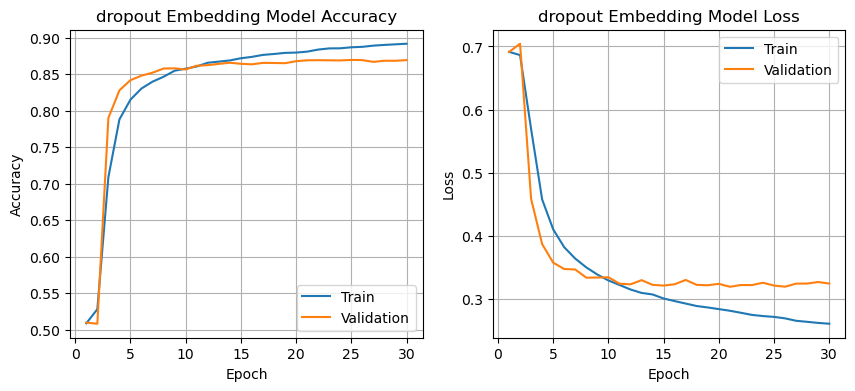

In [41]:
plot_history(history_dp, "dropout Embedding Model")

## 프로젝트 회고

이번 프로젝트에서는 네이버 영화 리뷰(NSMC) 데이터를 활용하여 감성 분석 모델을 구현하였다.  
형태소 분석(Mecab)을 통해 텍스트 데이터를 전처리하고, 단어를 인덱스 시퀀스로 변환한 뒤 LSTM 기반 분류 모델을 학습하였다.  
또한 랜덤 임베딩을 사용한 모델과 사전 학습된 Word2Vec 임베딩을 적용한 모델을 각각 구현하여 성능을 비교하였다.  
실험 결과 Word2Vec을 적용한 모델이 랜덤 임베딩 모델보다 validation accuracy가 소폭 높게 나타났으며,  
특히 학습 초기 단계에서 더 빠르게 성능이 안정화되는 경향을 확인할 수 있었다.  
이를 통해 사전 학습 임베딩이 초기 학습 과정에서 도움이 될 수 있다는 점을 확인하였다.
이번 프로젝트를 통해 한국어 텍스트 데이터를 처리하는 전처리 과정과 자연어 처리 모델의 기본적인 학습 흐름을 이해할 수 있었다.  
특히 형태소 분석, 단어 사전 구성, 패딩 처리 등 텍스트 데이터를 모델 입력 형태로 변환하는 과정의 중요성을 체감할 수 있었다.  
전체적으로 이번 프로젝트는 텍스트 데이터 처리부터 모델 학습,  
성능 비교까지 자연어 처리 파이프라인을 직접 구현해 볼 수 있었다는 점에서 의미 있는 경험이었다.  
또한 Dropout을 수행해보며, 실제로 소폭 overfitting이 